**Readme.MD**


https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset

This project aims to classify lung CT scan images into three categories, normal, benign and malignant. We used CNNs, to extract patterns from grayscale CT scan images and predict the likelihood of lung cancer. The goal is to assist in early detection and diagnosis of lung conditions through image analysis.

No special organization

To run:
Get your own Kaggle.json file. Go to the 'Account' tab of your user profile and select 'Create New Token'. This willdownload Kaggle.json. When promted to upload it, upload.


In [ ]:
!pip install numpy pandas matplotlib seaborn tensorflow keras opencv-python pydicom


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import cv2
import os
import pydicom


In [ ]:
from google.colab import files
files.upload()



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"emelie4","key":"c7e908c68fb16e89d01b8cb67a474863"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d adityamahimkar/iqothnccd-lung-cancer-dataset
!unzip iqothnccd-lung-cancer-dataset.zip


Dataset URL: https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
License(s): copyright-authors
Archive:  iqothnccd-lung-cancer-dataset.zip
  inflating: Test cases/000001_03_01_088.png  
  inflating: Test cases/000017_02_01_016.png  
  inflating: Test cases/000019_01_01_021.png  
  inflating: Test cases/000019_02_01_025.png  
  inflating: Test cases/000019_03_01_025.png  
  inflating: Test cases/000020_01_01_066.png  
  inflating: Test cases/000020_02_01_062.png  
  inflating: Test cases/000020_03_01_134.png  
  inflating: Test cases/000020_03_01_166.png  
  inflating: Test cases/000020_03_01_212.png  
  inflating: Test cases/000020_04_01_116.png  
  inflating: Test cases/000020_04_01_143.png  
  inflating: Test cases/000020_04_01_159.png  
  inflating: Test cases/000021_01_01_016.png  
  inflating: Test cases/000021_02_01_068.png  
  inflating: Test cases/000021_03_01_012.png  
  inflating: Test cases/000021_03_01_017.png  
  inflating: Test cases/000021_04_01_

In [ ]:
import os
print(os.listdir("./The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"))



['Bengin cases', 'IQ-OTH_NCCD lung cancer dataset.txt', 'Malignant cases', 'Normal cases']


In [ ]:
IMAGE_SIZE = 128
data = []
labels = []

dataset_path = "./The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"
categories = {
    "Normal": "Normal cases",
    "Benign": "Bengin cases",
    "Malignant": "Malignant cases"
}

for category, folder in categories.items():
    path = os.path.join(dataset_path, folder)
    label = list(categories.keys()).index(category)

    if not os.path.exists(path):
        print(f"Warning: {path} does not exist. Skipping...")
        continue

    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
            data.append(image)
            labels.append(label)
        except Exception as e:
            print(f"Error processing {img}: {e}")

data = np.array(data).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1) / 255.0
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)



from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels, num_classes=3)

Data shape: (1097, 128, 128, 1)
Labels shape: (1097,)


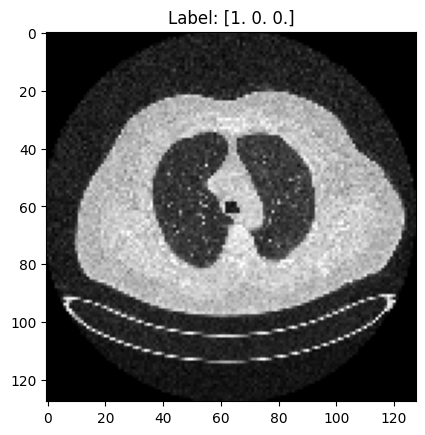

In [ ]:
plt.imshow(data[100].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
plt.title(f"Label: {labels[0]}")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=16,
    class_weight={0: 0.67, 1: 1.10, 2: 1.69}
)
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.5040 - loss: 1.0912 - val_accuracy: 0.5091 - val_loss: 0.8581
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6424 - loss: 0.7626 - val_accuracy: 0.7773 - val_loss: 0.5136
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7641 - loss: 0.4892 - val_accuracy: 0.9227 - val_loss: 0.3329
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8385 - loss: 0.3370 - val_accuracy: 0.9318 - val_loss: 0.2262
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9219 - loss: 0.2137 - val_accuracy: 0.9727 - val_loss: 0.0922
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9440 - loss: 0.1418 - val_accuracy: 0.9682 - val_loss: 0.0844
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9729 - loss: 0.0721 - val_accuracy: 0.9864 - val_loss: 0.0425
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9898 - loss: 0.0490 - val_accuracy: 0.9909 - v

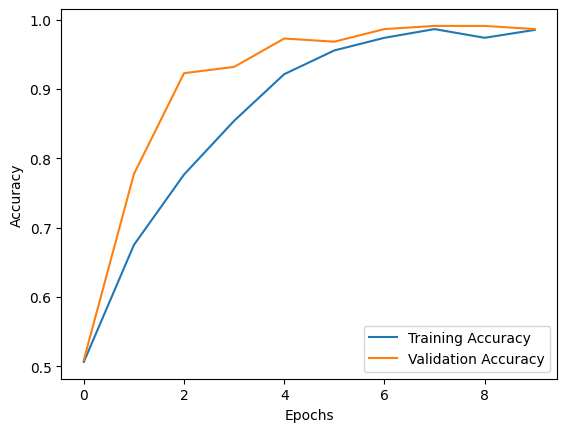

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
from google.colab import files

uploaded = files.upload()

index_to_category = {index: category for index, category in enumerate(categories.keys())}

for file_name in uploaded.keys():
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = img.reshape(1, IMAGE_SIZE, IMAGE_SIZE, 1) / 255.0

    prediction = model.predict(img)
    predicted_label = np.argmax(prediction)

    print(f"Prediction: {index_to_category[predicted_label]}")


Saving NDt.21.png to NDt.21.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction: Normal


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=["Normal", "Benign", "Malignant"]))

auc_score = roc_auc_score(y_test, y_pred, multi_class='ovo', average='macro')
print(f"AUC Score (macro-average): {auc_score:.2f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step
Confusion Matrix:
 [[ 89   0   0]
 [  2  17   0]
 [  0   1 111]]
Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        89
      Benign       0.94      0.89      0.92        19
   Malignant       1.00      0.99      1.00       112

    accuracy                           0.99       220
   macro avg       0.97      0.96      0.97       220
weighted avg       0.99      0.99      0.99       220

AUC Score (macro-average): 1.00
